# Assignment 4: Customer Segmentation with Clustering

**Student Name:** Tommy Flanagan

**Date:** 2/17/2026

---

## Assignment Overview

You've been hired as a data science consultant by a UK-based online gift retailer. They're spending the same amount on marketing to all customers regardless of value. Your task: segment their customer base using transaction data from 2009-2011, identify distinct customer groups, and provide actionable recommendations for each segment.

---

## Step 1: Import Libraries and Load Data

In [1]:
pip install pandas matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [3]:
# Load the Online Retail II dataset
# TODO: Load online_retail_II.csv from the data folder
df = pd.read_csv(r"C:\Users\flana\Downloads\online_retail_II.csv")

# Display basic information
# TODO: Display the first few rows and basic info about the dataset

print(df.head())
print(df.describe())
print(df.info())

print("\n" + "="*80)
print("CHECKPOINT: Verify dataset loaded correctly")
print(f"Dataset shape: {df.shape if df is not None else 'Not loaded'}")
print(f"Date range: [Check InvoiceDate column]")
print("="*80)

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
           Quantity         Price    Customer ID
count  1.067371e+06  1.067371e+06  824364.000000
mean   9.938898e+00  4.649388e+00   15324.638504
std    1.727058e+02  1.235531e+02    1697.464450
min   -8.099500e+

---
## Step 2: Aggregate Transaction Data to Customer-Level RFM Features

### Clean Transaction Data

Before aggregating to customer-level, clean the transaction data:
- Remove rows with missing Customer ID
- Remove returns (negative Quantity)
- Create TotalSpend column (Quantity × Price)
- Convert InvoiceDate to datetime

In [4]:
# Clean the data
print(df.columns.to_list())
# TODO: Remove missing Customer IDs

total_missing = df.isna().sum()

df = df.dropna(subset=['Customer ID'])
print(total_missing)

# TODO: Remove negative quantities (returns)

df = df[df['Price'] >= 0]
df = df[df['Quantity'] >= 0]

# TODO: Create TotalSpend column

df['TotalSpend'] = df['Quantity'] * df['Price']

# TODO: Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("\n" + "="*80)
print("CHECKPOINT: After data cleaning")
print(f"Remaining transactions: {len(df) if df is not None else 'N/A'}")
print(f"Unique customers: {df['Customer ID'].nunique() if df is not None else 'N/A'}")
print("="*80)

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

CHECKPOINT: After data cleaning
Remaining transactions: 805620
Unique customers: 5881


### Calculate RFM Features for Each Customer

Create three features for each customer:
- **Recency**: Days since last purchase (use December 10, 2011 as reference date)
- **Frequency**: Total number of unique invoices
- **Monetary**: Total amount spent

In [5]:
# Set reference date for recency calculation
reference_date = pd.to_datetime('2011-12-10')

# TODO: For each Customer ID, calculate:
# - Recency: (reference_date - max(InvoiceDate)).days
# - Frequency: count of unique Invoice numbers
# - Monetary: sum of TotalSpend

recency = df.groupby('Customer ID')['InvoiceDate'].max().apply(lambda x: (reference_date - x).days)
freq = df.groupby('Customer ID')['Invoice'].nunique()
monetary = df.groupby('Customer ID')['TotalSpend'].sum()

rfm_df =  (
    df.groupby('Customer ID').agg(
        Recency = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
        Frequency = ('Invoice', 'nunique'),
        Monetary = ('TotalSpend', 'sum')
    )
    .reset_index()
)

print("\n" + "="*80)
print("CHECKPOINT: RFM Features Created")
if rfm_df is not None:
    print(f"Number of customers: {len(rfm_df)}")
    print(f"\nRFM Summary Statistics:")
    print(rfm_df.describe())
print("="*80)


CHECKPOINT: RFM Features Created
Number of customers: 5881

RFM Summary Statistics:
        Customer ID      Recency    Frequency       Monetary
count   5881.000000  5881.000000  5881.000000    5881.000000
mean   15314.674205   200.992858     6.287196    3017.076888
std     1715.429759   209.489651    13.012879   14734.128619
min    12346.000000     0.000000     1.000000       0.000000
25%    13833.000000    25.000000     1.000000     347.800000
50%    15313.000000    95.000000     3.000000     897.620000
75%    16797.000000   379.000000     7.000000    2304.180000
max    18287.000000   738.000000   398.000000  608821.650000


---
## Step 3: Standardize Features and Determine Optimal k

### Standardize RFM Features

K-means is sensitive to feature scale, so standardize features to mean=0, std=1

In [6]:
# TODO: Use StandardScaler to standardize Recency, Frequency, and Monetary
features = rfm_df[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(features)  # Replace with scaled features

print("\n" + "="*80)
print("CHECKPOINT: Features Standardized")
if rfm_scaled is not None:
    print(f"Scaled features shape: {rfm_scaled.shape}")
    print(f"Mean of scaled features: {rfm_scaled.mean(axis=0)}")
    print(f"Std of scaled features: {rfm_scaled.std(axis=0)}")
print("="*80)


CHECKPOINT: Features Standardized
Scaled features shape: (5881, 3)
Mean of scaled features: [ 9.18232408e-17 -2.77886123e-17  2.41640107e-18]
Std of scaled features: [1. 1. 1.]


### Elbow Method: Test k from 2 to 10

Calculate inertia (within-cluster sum of squares) for different values of k

In [8]:
# TODO: Test k values from 2 to 10
# For each k:
#   - Train KMeans(n_clusters=k, random_state=42)
#   - Store inertia value'
from sklearn.cluster import KMeans

inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    kmeans.fit(rfm_scaled)

    inertias.append(kmeans.inertia_)
    print(f"k={k}: inertia={kmeans.inertia_:.2f}")
    
print("\n" + "="*80)
print("CHECKPOINT: Elbow Method Calculated")
print(f"Tested k values: {list(k_range)}")
print("="*80)

k=2: inertia=12120.40
k=3: inertia=7126.98
k=4: inertia=5168.48
k=5: inertia=3911.98
k=6: inertia=3305.97
k=7: inertia=2738.20
k=8: inertia=2254.98
k=9: inertia=1912.57
k=10: inertia=1650.09

CHECKPOINT: Elbow Method Calculated
Tested k values: [2, 3, 4, 5, 6, 7, 8, 9, 10]


Text(0.5, 1.0, 'Using Elbow Method to Determine Ideal Numbers of Clusters')

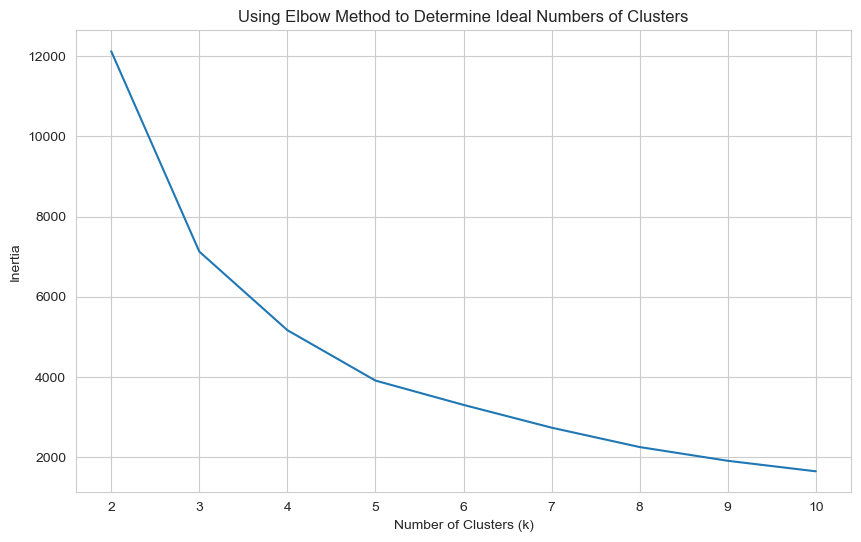

In [9]:
# TODO: Plot the elbow curve
# x-axis: k values
# y-axis: inertia

plt.figure(figsize=(10,6))
plt.plot(k_range, inertias)

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Using Elbow Method to Determine Ideal Numbers of Clusters')


### Silhouette Score Analysis

Calculate silhouette scores to validate cluster quality

In [10]:
# TODO: Calculate silhouette scores for k from 2 to 10
# For each k:
#   - Train KMeans
#   - Calculate silhouette_score(rfm_scaled, labels)

silhouette_scores = []

for k in k_range:
    # Train k-means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    
    # Calculate silhouette score
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score={score:.4f}")


print("\n" + "="*80)
print("CHECKPOINT: Silhouette Scores Calculated")
print("="*80)

k=2: silhouette score=0.9164
k=3: silhouette score=0.5803
k=4: silhouette score=0.5906
k=5: silhouette score=0.6030
k=6: silhouette score=0.5511
k=7: silhouette score=0.5493
k=8: silhouette score=0.5423
k=9: silhouette score=0.5355
k=10: silhouette score=0.5022

CHECKPOINT: Silhouette Scores Calculated


Text(0.5, 1.0, 'K Value and Silhouette Score Comparison')

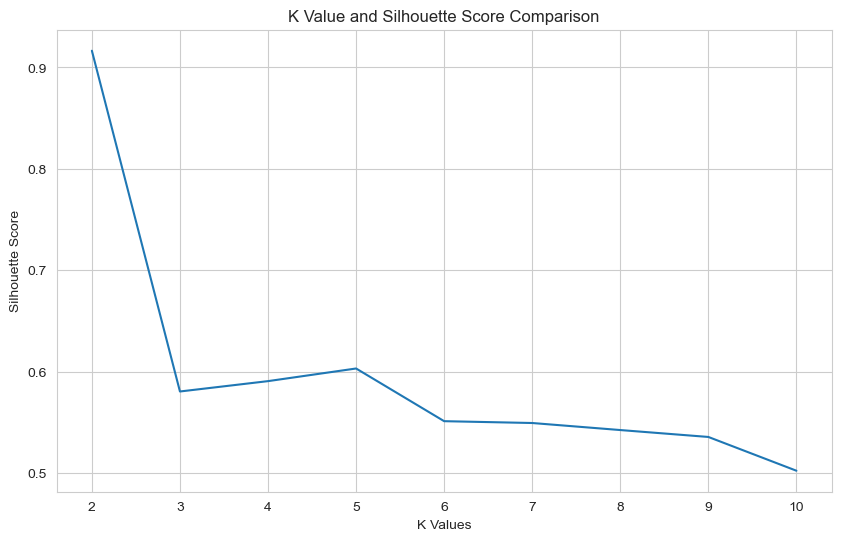

In [11]:
# TODO: Plot silhouette scores
# x-axis: k values
# y-axis: silhouette score

plt.figure(figsize=(10,6))
plt.plot(k_range, silhouette_scores)

plt.xlabel('K Values')
plt.ylabel('Silhouette Score')
plt.title('K Value and Silhouette Score Comparison')



### Select Optimal k

**Your k selection justification (write 2-3 sentences):**

[Based on the elbow plot and silhouette scores, explain why you chose your k value. What did you observe at the elbow point? What were the silhouette scores like for different k values?]

In [12]:
# TODO: Set your chosen k value
optimal_k = 3  # Replace with your chosen k (e.g., 4, 5, or 6)

print(f"Chosen k value: {optimal_k}")

Chosen k value: 3


---
## Step 4: Train K-Means Model and Visualize Segments

### Train Final K-Means Model

In [13]:
# TODO: Train KMeans with your optimal_k and random_state=42
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# TODO: Add cluster labels to rfm_df
rfm_df['Cluster'] = kmeans.fit_predict(rfm_scaled)


print("\n" + "="*80)
print("CHECKPOINT: K-Means Model Trained")
print(f"Number of clusters: {optimal_k}")
if 'Cluster' in rfm_df.columns:
    print(f"\nCluster sizes:")
    print(rfm_df['Cluster'].value_counts().sort_index())
print("="*80)


CHECKPOINT: K-Means Model Trained
Number of clusters: 3

Cluster sizes:
Cluster
0    2020
1      18
2    3843
Name: count, dtype: int64


### Visualize Customer Segments

Create a 2D scatter plot showing Frequency vs Monetary, colored by cluster

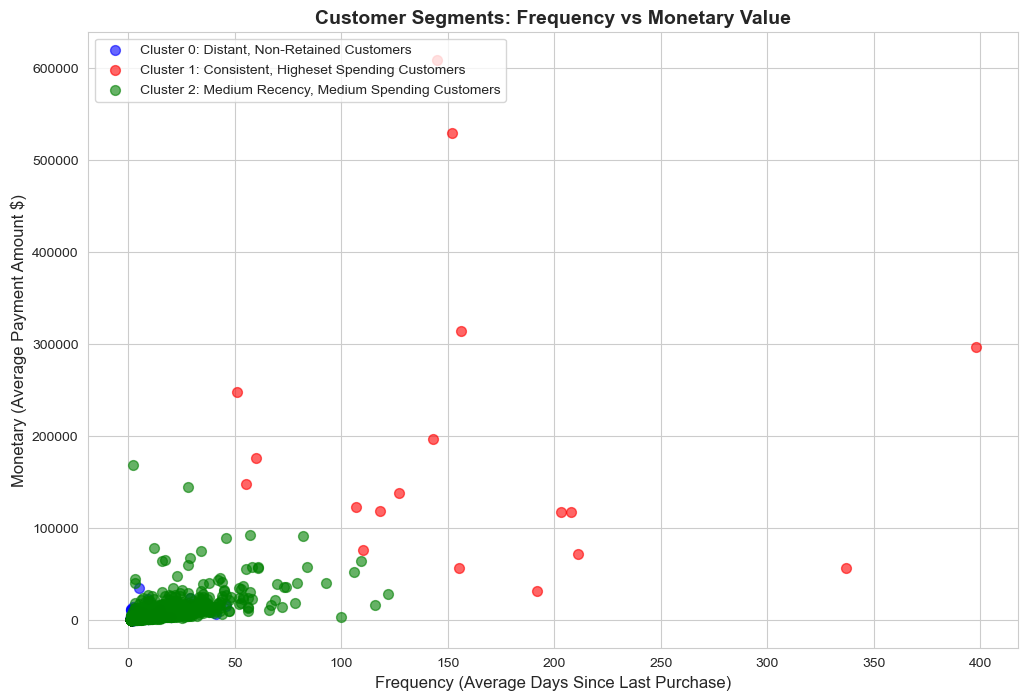

In [14]:
# TODO: Create scatter plot
# x-axis: Frequency
# y-axis: Monetary
# color: Cluster
# Include legend

plt.figure(figsize=(12,8))

colors = {0: 'blue', 1: 'red', 2: 'green'}
labels = {
    0: 'Cluster 0: Distant, Non-Retained Customers',
    1: 'Cluster 1: Consistent, Higheset Spending Customers',
    2: 'Cluster 2: Medium Recency, Medium Spending Customers',
}

for cluster in range(3):
    cluster_data = rfm_df[rfm_df['Cluster'] == cluster]
    plt.scatter(
        cluster_data['Frequency'], 
        cluster_data['Monetary'],
        c=colors[cluster],
        label=labels[cluster],
        alpha=0.6,
        s=50
    )

plt.xlabel('Frequency (Average Days Since Last Purchase)', fontsize=12)
plt.ylabel('Monetary (Average Payment Amount $)', fontsize=12)
plt.title('Customer Segments: Frequency vs Monetary Value', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=10)



### Calculate Cluster Centers

Show the mean RFM values for each cluster

In [15]:
# TODO: Calculate mean Recency, Frequency, and Monetary for each cluster


print("\n" + "="*80)
print("CLUSTER CENTERS (Mean RFM Values)")
print("="*80)
# TODO: Display cluster_summary

cluster_summary_mean = rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_summary_median = rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].median()
cluster_summary_min = rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].min()
cluster_summary_max = rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].max()

print(f"\nCluster characteristics (Mean):")
print(cluster_summary_mean)

print(f"\nCluster characteristics (Median):")
print(cluster_summary_median)

print(f"\nCluster characteristics (Min):")
print(cluster_summary_min)

print(f"\nCluster characteristics (Max):")
print(cluster_summary_max)

print("="*80)


CLUSTER CENTERS (Mean RFM Values)

Cluster characteristics (Mean):
            Recency   Frequency       Monetary
Cluster                                       
0        460.705446    2.210396     763.965026
1         24.833333  162.666667  189805.090000
2         65.304970    7.697632    3326.497061

Cluster characteristics (Median):
         Recency  Frequency   Monetary
Cluster                               
0          429.0        1.0     381.49
1            1.5      148.5  130013.83
2           40.0        5.0    1373.35

Cluster characteristics (Min):
         Recency  Frequency  Monetary
Cluster                              
0            246          1      0.00
1              0         51  30861.06
2              0          1      0.00

Cluster characteristics (Max):
         Recency  Frequency   Monetary
Cluster                               
0            738         46   34095.26
1            372        398  608821.65
2            372        122  168472.50


---
## Step 5: Interpret Segments and Provide Business Recommendations

### Segment 0: Distant, Non-Retained Customers

**Customer Profile (3-5 sentences):**

This segment has the higheset recency and lowest frequency by far. For the context, this means that they have bought something the furthest on average from the current date while also buying the fewest items. This means they probably came in a long time ago, bought a couple things, and then left and never came back. Most likely, these are people who were just passing through the area. 

For a marketing strategy, minimal resources should be put toward these people. They are not valuable customers because their retention rate is most likely very low. The reasoning does not matter (not impressed with product, passing through, new to area, etc.). What matters is they are not going to be back in all liklihood, so any effort to have them return would be a waste of resources.

In [17]:
# TODO: Calculate detailed statistics for Segment 0
# Show mean, median, min, max for R, F, M

print("Mean Outputs for Segment 0:")
print(cluster_summary_mean.loc[0])
print("\n")

print("Median Outputs for Segment 0:")
print(cluster_summary_median.loc[0])
print("\n")

print("Min Outputs for Segment 0:")
print(cluster_summary_min.loc[0])
print("\n")

print("Max Output for Segment 0:")
print(cluster_summary_max.loc[0])
print("\n")


Mean Outputs for Segment 0:
Recency      460.705446
Frequency      2.210396
Monetary     763.965026
Name: 0, dtype: float64


Median Outputs for Segment 0:
Recency      429.00
Frequency      1.00
Monetary     381.49
Name: 0, dtype: float64


Min Outputs for Segment 0:
Recency      246.0
Frequency      1.0
Monetary       0.0
Name: 0, dtype: float64


Max Output for Segment 0:
Recency        738.00
Frequency       46.00
Monetary     34095.26
Name: 0, dtype: float64




### Segment 1: Consistent, High-Spending Customers

**Customer Profile (3-5 sentences):**

These customers come back often, around once a month. These are people who come in at that rate and spend a boatload of money on various amounts of products. These are highly valued people because even though they don't come in on multiple occassions, they come in consitently and spend a ton of money when they do.

For marketing to these people, any effor to get them in on a regular basis would be great. Certain discount or different sale regimes would be good for getting them into the door. Also, a rewards program of sorts for them would be beneficial for both parties. 

In [18]:
# TODO: Calculate detailed statistics for Segment 1

print("Mean Outputs for Segment 1:")
print(cluster_summary_mean.loc[1])
print("\n")

print("Median Outputs for Segment 1:")
print(cluster_summary_median.loc[1])
print("\n")

print("Min Outputs for Segment 1:")
print(cluster_summary_min.loc[1])
print("\n")

print("Max Output for Segment 1:")
print(cluster_summary_max.loc[1])
print("\n")


Mean Outputs for Segment 1:
Recency          24.833333
Frequency       162.666667
Monetary     189805.090000
Name: 1, dtype: float64


Median Outputs for Segment 1:
Recency           1.50
Frequency       148.50
Monetary     130013.83
Name: 1, dtype: float64


Min Outputs for Segment 1:
Recency          0.00
Frequency       51.00
Monetary     30861.06
Name: 1, dtype: float64


Max Output for Segment 1:
Recency         372.00
Frequency       398.00
Monetary     608821.65
Name: 1, dtype: float64




### Segment 2: Medium Recency, Medium Spending Customers

**Customer Profile (3-5 sentences):**

This demographic falls in the middle of the previous two. They come in around once every two months, buy a smaller amount of items but still spend a good deal of money. 

For these people, the sales and discount sales would be best for them as opposed to a rewards program. This encourages them to get in the building and make some purchases.

In [19]:
# TODO: Calculate detailed statistics for Segment 2

print("Mean Outputs for Segment 2")
print(cluster_summary_mean.loc[2])
print("\n")

print("Median Outputs for Segment 2:")
print(cluster_summary_median.loc[2])
print("\n")

print("Min Outputs for Segment 2:")
print(cluster_summary_min.loc[2])
print("\n")

print("Max Output for Segment 2:")
print(cluster_summary_max.loc[2])
print("\n")


Mean Outputs for Segment 2
Recency        65.304970
Frequency       7.697632
Monetary     3326.497061
Name: 2, dtype: float64


Median Outputs for Segment 2:
Recency        40.00
Frequency       5.00
Monetary     1373.35
Name: 2, dtype: float64


Min Outputs for Segment 2:
Recency      0.0
Frequency    1.0
Monetary     0.0
Name: 2, dtype: float64


Max Output for Segment 2:
Recency         372.0
Frequency       122.0
Monetary     168472.5
Name: 2, dtype: float64




---
## Business Recommendations

### Recommendation 1: Abandon if any resources are being used

**Which segment(s) does this target?** Segment 0 - Distant, Non-Retained Customers

**Recommendation (3-5 sentences):**

These customers are not returning. For various reasons, they have not returend on average in over a year and did not buy that much product anyways. If any resources are being spent to market for their return, those should be cut and diverted to a better cause for increasing revenue.

### Recommendation 2: Create Rewards Program

**Which segment(s) does this target?** Segment 1 - Consistent, High-Spending Customers

**Recommendation (3-5 sentences):**

These should be your highest valued customers because they have the highest recency mean while also spending the most money and buying the most product. A rewards program for these would be best because it rewards them and creates a sense of loyalty that is very important for future performance. If possible, it will also help bring them into the store more.

### Recommendation 3: Target with Sales and Discounts

**Which segment(s) does this target?** Segment 2 - Medium Recency, Medium Spending Customers

**Recommendation (3-5 sentences):**

These customers fall in the middle of the two previous groups. Their recency is not far gone like it is for Segment 0. However, they are still valuable to where marketing resources should be used on them. Targeting them with sales and discount campaigns would be best because it increases the chance that some of them get in teh building and spend some money. With the money they spend at the store, it is worth allocating resources to try and increase their involvement in spending money there.

---
## Step 6: Submit Your Work

Before submitting:
1. Make sure all code cells run without errors
2. Verify you have:
   - RFM features properly calculated
   - Elbow method and silhouette score visualizations
   - Written justification for your k selection
   - Customer segment scatter plot
   - Descriptive names and profiles for each segment
   - Three specific business recommendations
3. Check that all visualizations display correctly

Then push to GitHub:
```bash
git add .
git commit -m 'completed customer segmentation assignment'
git push
```

Submit your GitHub repository link on the course platform.